In [10]:
'''
Author: DawSine Bai
LastEditors: DawSine Bai
LastEditTime: 2025-11-21 22:31:12
Description: State-Space Method for Displacement Formulation in Anisotropic Elasticity (Assignment 6)
Course: 2025 Fall Anisotropic Elasticity, Guojun Nie, Tongji University,
'''

import numpy as np
import scipy.linalg
from scipy.linalg import expm
import matplotlib.pyplot as plt
import sympy as sp
from sympy import symbols, diff, exp, sin, cos, pi, Matrix, simplify, lambdify
from IPython.display import Math, display 
sp.init_printing(use_latex="mathjax")



# State Space Method 2: Displacement-Base

# Part.1 符号推导 (Symbolic Derivation)

In [11]:
# ==========================================
# 第一部分：符号推导 (Symbolic Derivation)
# ==========================================
# 1. 定义基础符号\
# 注意：eta 必须是独立符号，不能定义为 z/h，否则无法求导
x, z, l, h, lam = symbols('x z l h lambda')
eta = symbols('eta') 
c11_0, c13_0, c33_0, c55_0 = symbols('c11_0 c13_0 c33_0 c55_0')
n = symbols('n', integer=True)

# 无量纲坐标关系 (仅用于理解，代码中通过链式法则体现)
# xi = x / l
# eta = z / h

In [12]:
# 2. 定义位移场 (Displacement Field)
# U_n(eta) 和 W_n(eta) 是关于无量纲坐标 eta 的函数
U_n = sp.Function('U_n')(eta)
W_n = sp.Function('W_n')(eta)

# 实际位移 (分离变量形式)
# u(x,z)
u = h * U_n * cos(n * pi * x / l)
# w(x,z)
w = h * W_n * sin(n * pi * x / l)

display(Math("u(x,z) = " + sp.latex(u)))
display(Math("w(x,z) = " + sp.latex(w)))

<IPython.core.display.Math object>

<IPython.core.display.Math object>

In [13]:
# 3. 几何方程 (Strain-Displacement)
# d/dz = (1/h) * d/d(eta) 手动应用链式法则处理 z 方向导数

eps_x = diff(u, x)
display(Math(r"\varepsilon_x = \frac{\partial u}{\partial x} = " + sp.latex(eps_x)))

# eps_z = du/dz = (1/h) * diff(w, eta)
eps_z = (1/h) * diff(w, eta)
display(Math(r"\varepsilon_z = \frac{\partial w}{\partial z} = \frac{1}{h} \frac{\partial w}{\partial \eta} = " + sp.latex(eps_z)))

# gamma_zx = dw/dx + du/dz
gamma_zx = diff(w, x) + (1/h) * diff(u, eta)
display(Math(r"\gamma_{zx} = \frac{\partial w}{\partial x} + \frac{1}{h} \frac{\partial u}{\partial \eta} = " + sp.latex(gamma_zx)))

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

In [14]:
# 4. 本构方程 (Constitutive Equations - FGM)
# 材料参数随 z (即 eta) 指数变化: c(z) = c0 * exp(lambda * z)
# z = h * eta
factor = exp(lam * h * eta)

sigma_x = factor * (c11_0 * eps_x + c13_0 * eps_z)
sigma_z = factor * (c13_0 * eps_x + c33_0 * eps_z)
tau_zx = factor * c55_0 * gamma_zx

display(Math(r"\sigma_x = " + sp.latex(sigma_x)))
display(Math(r"\sigma_z = " + sp.latex(sigma_z)))
display(Math(r"\tau_{zx} = " + sp.latex(tau_zx)))

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

In [15]:
# 5. 平衡方程 (Equilibrium Equations)
# eq1: d(sigma_x)/dx + d(tau_zx)/dz = 0
# eq2: d(tau_zx)/dx + d(sigma_z)/dz = 0
# 同样应用链式法则: d/dz -> (1/h)*d/eta

eq1 = diff(sigma_x, x) + (1/h) * diff(tau_zx, eta)
eq2 = diff(tau_zx, x) + (1/h) * diff(sigma_z, eta)

display(Math(r"\text{Equilibrium Equation 1: } " + sp.latex(simplify(eq1)) + " = 0"))
display(Math(r"\text{Equilibrium Equation 2: } " + sp.latex(simplify(eq2)) + " = 0"))

<IPython.core.display.Math object>

<IPython.core.display.Math object>

In [16]:
# 6. 化简方程
# 消除公因子 exp(lambda * h * eta)
# 注意：在求导过程中，exp项的导数会产生 lambda 因子，必须先求导再除以 factor
eq1 = simplify(eq1 / factor)
eq2 = simplify(eq2 / factor)
display(Math(r"\text{Simplified Eq1: } " + sp.latex(eq1) + " = 0"))
display(Math(r"\text{Simplified Eq2: } " + sp.latex(eq2) + " = 0"))

# 提取关于 sin/cos 的系数，使其对任意 x 成立
# eq1 包含 cos(n*pi*x/l)
# eq2 包含 sin(n*pi*x/l)
eq1_coeffs = eq1.coeff(cos(n * pi * x / l))
eq2_coeffs = eq2.coeff(sin(n * pi * x / l))
display(Math(r"\text{Eq1 Coefficients: } " + sp.latex(eq1_coeffs) + " = 0"))
display(Math(r"\text{Eq2 Coefficients: } " + sp.latex(eq2_coeffs) + " = 0"))

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

In [17]:
# 7. 构建状态空间方程
# 目标: d/d(eta) [U, W, U', W']^T = A * [U, W, U', W']^T
# 我们需要解出 U'' (d2U) 和 W'' (d2W)

dU = diff(U_n, eta)
dW = diff(W_n, eta)
d2U = diff(U_n, eta, 2)
d2W = diff(W_n, eta, 2)
display(Math(r"U' = " + sp.latex(dU)))
display(Math(r"W' = " + sp.latex(dW)))
display(Math(r"U'' = " + sp.latex(d2U)))
display(Math(r"W'' = " + sp.latex(d2W)))


# 求解代数方程组
sol = sp.solve([eq1_coeffs, eq2_coeffs], [d2U, d2W])
display(Math(r"U'' = " + sp.latex(sol[d2U])))
display(Math(r"W'' = " + sp.latex(sol[d2W])))

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

In [18]:
# 8. 提取矩阵 A
# 状态向量顺序: Y = [U_n, W_n, U_n', W_n']
# Y' = [U_n', W_n', U_n'', W_n'']

A = sp.zeros(4, 4)

# Row 1: d(U)/d(eta) = U'
A[0, 2] = 1 
# Row 2: d(W)/d(eta) = W'
A[1, 3] = 1 

# Row 3 & 4: 来自平衡方程解出的 U'' 和 W''
# sol[d2U] 和 sol[d2W] 是 U, W, U', W' 的线性组合
vars_list = [U_n, W_n, dU, dW]

for i, var in enumerate(vars_list):
    A[2, i] = sol[d2U].coeff(var)
    A[3, i] = sol[d2W].coeff(var)

A_matrix_sym, params_sym = A, (c11_0, c13_0, c33_0, c55_0, l, h, lam, n)
display(Math(r"\text{State-Space Matrix } A = " + sp.latex(A_matrix_sym)))

<IPython.core.display.Math object>

# Part.2 数值计算 (Numerical computation)

In [19]:
# ==========================================
# 第二部分：数值计算 (Assignment 6)
# ==========================================
# 数值计算 Numberical Evaluation of N
# 参数设置
L_val = 1.0       # m
h_val = 0.2       # m
c11_val = 41.3    # GPa
c13_val = 10.1    # GPa
c33_val = 36.2    # GPa
c55_val = 10.0    # GPa

# 载荷: q(x) = sin(pi*x/l) MPa
# 统一单位为 GPa: 1 MPa = 0.001 GPa
q0_val = 0.001 
n_val = 1 

# Lambda 梯度指数
lambdas = [-2, -1, 0, 1, 2]

# 离散化厚度方向用于绘图
z_eval = np.linspace(0, h_val, 50) 
eta_eval = z_eval / h_val

results = {}

# 将 SymPy 矩阵转换为 Numpy 可调用函数来提高循环计算的速度
func_A = lambdify(params_sym, A_matrix_sym, modules='numpy')

In [20]:
for lam_val in lambdas:
    # 1. 计算当前 lambda 下的数值矩阵 A
    A_num = func_A(c11_val, c13_val, c33_val, c55_val, L_val, h_val, lam_val, n_val)
    A_num = np.array(A_num).astype(np.float64)
    
    # 2. 构建边界条件求解初始向量 Psi(0)
    # 状态向量 Psi = [U, W, U', W']^T
    
    # 需要构建矩阵 K * Psi(0) = F
    # 其中 K 包含 z=0 和 z=h 处的应力边界条件
    
    alpha = n_val * np.pi / L_val
    
    # 定义辅助函数：根据状态变量计算应力幅值
    # 返回矩阵 M，使得 [sigma_z, tau_zx]^T = M * Psi
    def get_stress_coef_matrix(eta_loc):
        z_loc = eta_loc * h_val
        # 材料梯度因子
        mat_factor = np.exp(lam_val * z_loc)
        
        # Sigma_z = factor * (c13 * du/dx + c33 * dw/dz)
        # du/dx -> h*U*(-alpha)
        # dw/dz -> (1/h)*h*W' = W'
        # Sigma_z = factor * ( -c13*h*alpha * U + c33 * W' )
        # 对应状态变量 [U, W, U', W'] 的系数:
        row_sig = np.array([ -c13_val * h_val * alpha, 0, 0, c33_val ]) * mat_factor
        
        # Tau_zx = factor * c55 * (dw/dx + du/dz)
        # dw/dx -> h*W*(alpha)
        # du/dz -> U'
        # Tau_zx = factor * c55 * ( h*alpha * W + U' )
        row_tau = np.array([ 0, c55_val * h_val * alpha, c55_val, 0 ]) * mat_factor
        
        return np.vstack([row_sig, row_tau])

    # A. 下表面 (eta=0) 边界条件
    M_0 = get_stress_coef_matrix(0.0)
    
    # B. 上表面 (eta=1) 边界条件
    # 利用传递矩阵 T = exp(A * 1) 将上表面状态关联到初始状态
    # Psi(1) = T * Psi(0)
    T_matrix = expm(A_num * 1.0)
    M_1_local = get_stress_coef_matrix(1.0)
    M_1 = M_1_local @ T_matrix # 链式法则: M_1_local * (T * Psi_0)
    
    # 组装总刚度矩阵 K (4x4)
    K = np.vstack([M_0, M_1])
    
    # 组装载荷向量 F
    # eta=0: sigma_z = q0, tau_zx = 0
    # eta=1: sigma_z = 0,  tau_zx = 0
    F = np.array([q0_val, 0, 0, 0])
    
    # 求解线性方程组得到 Psi(0)
    Psi_0 = np.linalg.solve(K, F)
    
    # 3. 回代计算沿厚度的分布
    u_amp_list = []
    sig_x_amp_list = []
    
    for eta in eta_eval:
        # 当前位置的状态向量
        T_curr = expm(A_num * eta)
        Psi_curr = T_curr @ Psi_0
        
        U_val, W_val, dU_val, dW_val = Psi_curr
        
        # 计算物理量 (幅值)
        # u = h * U
        u_amp_val = h_val * U_val
        u_amp_list.append(u_amp_val)
        
        # sigma_x = factor * (c11 * eps_x + c13 * eps_z)
        # eps_x = du/dx -> -h*alpha*U
        # eps_z = dw/dz -> W'
        z_loc = eta * h_val
        mat_factor = np.exp(lam_val * z_loc)
        
        sig_x_val = mat_factor * (c11_val * (-h_val * alpha * U_val) + c13_val * dW_val)
        sig_x_amp_list.append(sig_x_val)
        
    results[lam_val] = {
        'z': z_eval,
        'u': np.array(u_amp_list),
        'sigma_x': np.array(sig_x_amp_list)
    }
    


# Part.3 结果可视化

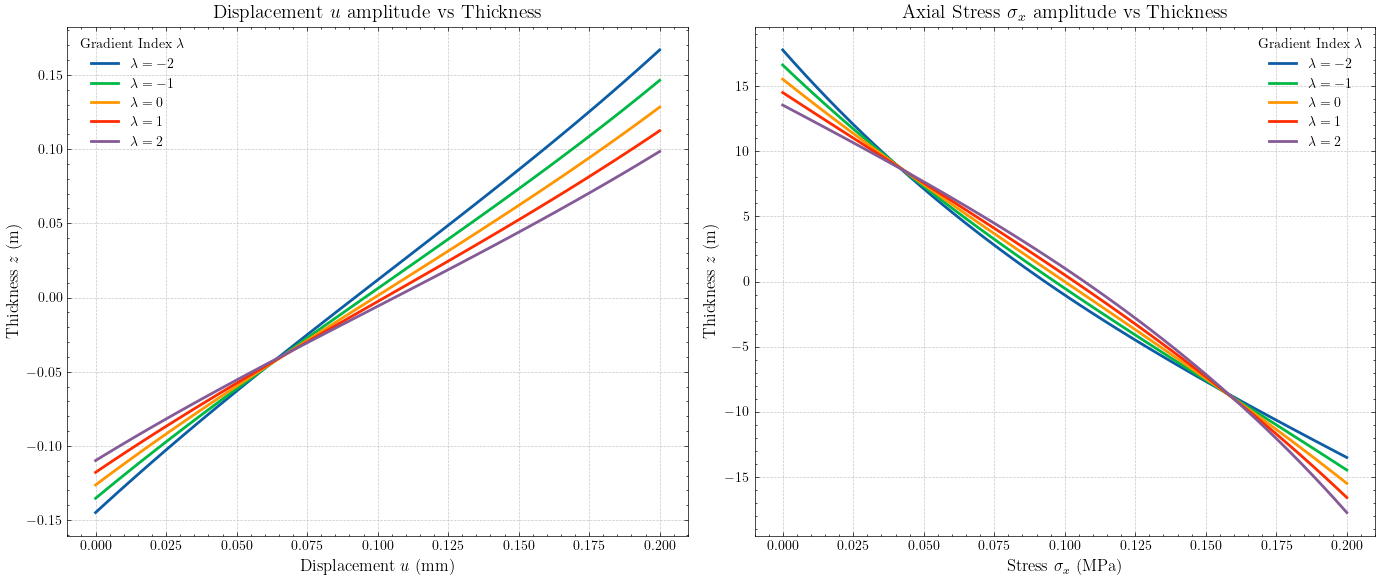

In [21]:
# ==========================================
# 第三部分：结果可视化
# ==========================================
import scienceplots
plt.style.use('science')

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

# 图1: 水平位移 u 沿厚度分布
for lam, data in results.items():
    # 转换为 mm
    ax1.plot(data['z'], data['u'] * 1000, label=f'$\lambda={lam}$', linewidth=2)

ax1.set_title('Displacement $u$ amplitude vs Thickness', fontsize=14)
ax1.set_xlabel('Displacement $u$ (mm)', fontsize=12)
ax1.set_ylabel('Thickness $z$ (m)', fontsize=12)
ax1.grid(True, linestyle='--', alpha=0.7)
ax1.legend(title='Gradient Index $\lambda$')

# 图2: 正应力 sigma_x 沿厚度分布
for lam, data in results.items():
    # 转换为 MPa (原始计算单位为 GPa)
    ax2.plot(data['z'], data['sigma_x'] * 1000, label=f'$\lambda={lam}$', linewidth=2)

ax2.set_title('Axial Stress $\sigma_x$ amplitude vs Thickness', fontsize=14)
ax2.set_xlabel('Stress $\sigma_x$ (MPa)', fontsize=12)
ax2.set_ylabel('Thickness $z$ (m)', fontsize=12)
ax2.grid(True, linestyle='--', alpha=0.7)
ax2.legend(title='Gradient Index $\lambda$')

plt.tight_layout()
plt.show()


In [22]:
# ==========================================
# Ending
# ==========================================